# K-Nearest Neighbors (KNN) Classifier - MLE Interview Prep

## Introduction

### What is KNN?

**K-Nearest Neighbors (KNN)** is a **non-parametric, instance-based (lazy) learning** algorithm used for classification and regression tasks.

**Key Characteristics:**
- **Lazy Learning**: No explicit training phase - all computation happens at prediction time
- **Non-parametric**: Makes no assumptions about the underlying data distribution
- **Instance-based**: Uses the entire training dataset to make predictions
- **Simple but powerful**: Can learn complex non-linear decision boundaries

### Algorithm Overview

**For Classification:**
1. Given a test point, compute distances to all training points
2. Select the k nearest neighbors
3. Predict the class by majority vote among k neighbors
4. Handle ties (e.g., use closest neighbor's label)

**For Regression:**
1. Same as above, but predict the average (or weighted average) of k neighbors' values

### Distance Metrics

KNN relies on distance metrics to find the nearest neighbors. Here are the most common distance metrics with their mathematical formulations:

#### 1. Euclidean Distance (L2 Norm)

The most common distance metric, representing the straight-line distance between two points:

$$d_{euclidean}(x, y) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2} = \sqrt{(x_1 - y_1)^2 + (x_2 - y_2)^2 + \cdots + (x_n - y_n)^2}$$

**In vector form:**
$$d_{euclidean}(x, y) = \|x - y\|_2 = \sqrt{(x - y)^T(x - y)}$$

**Properties:**
- Most intuitive (straight-line distance)
- Sensitive to outliers
- Good for continuous features with similar scales

#### 2. Manhattan Distance (L1 Norm)

Also known as taxicab distance, representing the sum of absolute differences:

$$d_{manhattan}(x, y) = \sum_{i=1}^{n} |x_i - y_i| = |x_1 - y_1| + |x_2 - y_2| + \cdots + |x_n - y_n|$$

**In vector form:**
$$d_{manhattan}(x, y) = \|x - y\|_1 = \sum_{i=1}^{n} |x_i - y_i|$$

**Properties:**
- Less sensitive to outliers than Euclidean
- Good for sparse data
- Computationally faster (no square root)

#### 3. Minkowski Distance (Generalized)

A generalization of both Euclidean and Manhattan distances:

$$d_{minkowski}(x, y) = \left(\sum_{i=1}^{n} |x_i - y_i|^p\right)^{1/p}$$

**Special cases:**
- When $p = 1$: Manhattan distance
- When $p = 2$: Euclidean distance
- When $p \to \infty$: Chebyshev distance (maximum coordinate difference)

**In our implementation:**
We use $p = 3$ as an example:
$$d_{minkowski}(x, y) = \left(\sum_{i=1}^{n} |x_i - y_i|^3\right)^{1/3}$$

#### 4. Chebyshev Distance (L∞ Norm)

The maximum coordinate difference:

$$d_{chebyshev}(x, y) = \max_{i} |x_i - y_i| = \lim_{p \to \infty} \left(\sum_{i=1}^{n} |x_i - y_i|^p\right)^{1/p}$$

**Properties:**
- Only considers the dimension with maximum difference
- Useful in chess (king moves) and certain optimization problems

#### Distance Metric Comparison

| Metric | Formula | p-value | Sensitivity to Outliers | Use Case |
|--------|---------|---------|------------------------|----------|
| **Euclidean** | $\sqrt{\sum (x_i - y_i)^2}$ | p=2 | High | Continuous features, similar scales |
| **Manhattan** | $\sum \|x_i - y_i\|$ | p=1 | Low | Sparse data, categorical-like features |
| **Minkowski** | $(\sum \|x_i - y_i\|^p)^{1/p}$ | p>0 | Medium | General purpose, configurable |
| **Chebyshev** | $\max \|x_i - y_i\|$ | p=∞ | Very Low | Maximum difference matters |

### Why KNN is Important for MLE Interviews

- Tests understanding of **distance metrics** (Euclidean, Manhattan, etc.)
- Demonstrates knowledge of **bias-variance tradeoff** (how k affects model complexity)
- Shows awareness of **computational complexity** (O(n×d) prediction time)
- Illustrates **feature scaling importance** (distance-based algorithms are scale-sensitive)
- Common in real-world applications (recommendation systems, similarity search, anomaly detection)

### Real-World Applications

- **Recommendation Systems**: "Users who bought X also bought Y"
- **Image Classification**: Find similar images
- **Anomaly Detection**: Identify points far from neighbors
- **Medical Diagnosis**: Find similar patient cases
- **Text Classification**: Classify documents based on similar documents


In [6]:
import numpy as np
from collections import Counter

class KNNClassifier:
    """
    K-Nearest Neighbors Classifier
    
    Parameters:
    -----------
    k : int, default=3
        Number of neighbors to use for prediction
    distance_metric : str, default='euclidean'
        Distance metric to use ('euclidean', 'manhattan', 'minkowski')
    """
    
    def __init__(self, k=3, distance_metric='euclidean'):
        # Validate k
        if k <= 0:
            raise ValueError(f"k must be positive, got {k}")
        
        # Validate distance metric
        valid_metrics = ['euclidean', 'manhattan', 'minkowski']
        if distance_metric not in valid_metrics:
            raise ValueError(f"Unknown distance metric: {distance_metric}. Must be one of {valid_metrics}")
        
        self.k = k
        self.distance_metric = distance_metric
        self._is_fitted = False
        
    def fit(self, X, y):
        """
        Store training data (lazy learning - no training needed)
        
        Parameters:
        -----------
        X : array-like of shape (n_samples, n_features)
            Training samples
        y : array-like of shape (n_samples,)
            Target values
        """
        X = np.array(X)
        y = np.array(y)
        
        # Validate empty dataset
        if X.size == 0 or len(X) == 0:
            raise ValueError("X cannot be empty")
        
        # Validate mismatched lengths
        if len(X) != len(y):
            raise ValueError(f"X and y must have the same length, got X: {len(X)}, y: {len(y)}")
        
        self.X_train = X
        self.y_train = y
        
        # Validate k
        if self.k > len(self.X_train):
            raise ValueError(f"k ({self.k}) cannot be larger than number of training samples ({len(self.X_train)})")
        
        self._is_fitted = True
        return self
    
    def _compute_distance(self, x1, x2):
        """Compute distance between two points"""
        if self.distance_metric == 'euclidean':
            return np.sqrt(np.sum((x1 - x2) ** 2))
        elif self.distance_metric == 'manhattan':
            return np.sum(np.abs(x1 - x2))
        elif self.distance_metric == 'minkowski':
            # Minkowski with p=3
            return np.power(np.sum(np.power(np.abs(x1 - x2), 3)), 1/3)
        else:
            raise ValueError(f"Unknown distance metric: {self.distance_metric}")
    
    def _predict_single(self, x):
        """
        Predict class for a single sample
        
        Steps:
        1. Compute distances to all training points
        2. Get k nearest neighbors
        3. Majority vote (with tie-breaking)
        """
        # 1. Compute distances
        distances = np.array([self._compute_distance(x, x_train) 
                             for x_train in self.X_train])
        
        # 2. Get k nearest neighbors
        k_indices = np.argsort(distances)[:self.k]
        k_labels = self.y_train[k_indices]
        
        # 3. Majority vote (handle ties by choosing closest)
        label_counts = Counter(k_labels)
        max_count = max(label_counts.values())
        
        # If tie, choose label of closest neighbor
        if list(label_counts.values()).count(max_count) > 1:
            # Tie-breaking: use closest neighbor's label
            return k_labels[0]
        else:
            # Return most common label
            most_common = label_counts.most_common(1)
            return most_common[0][0]
    
    def predict(self, X):
        """
        Predict classes for multiple samples
        
        Parameters:
        -----------
        X : array-like of shape (n_samples, n_features)
            Test samples
            
        Returns:
        --------
        predictions : ndarray of shape (n_samples,)
            Predicted class labels
        """
        if not self._is_fitted:
            raise ValueError("This KNNClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this method.")
        
        X = np.array(X)
        predictions = []
        for x in X:
            pred = self._predict_single(x)
            predictions.append(pred)
        return np.array(predictions)
    
    def predict_proba(self, X):
        """
        Predict class probabilities for multiple samples
        
        Parameters:
        -----------
        X : array-like of shape (n_samples, n_features)
            Test samples
            
        Returns:
        --------
        probabilities : ndarray of shape (n_samples, n_classes)
            Class probabilities
        """
        if not self._is_fitted:
            raise ValueError("This KNNClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this method.")
        
        X = np.array(X)
        probabilities = []
        classes = np.unique(self.y_train)
        
        for x in X:
            # Compute distances
            distances = np.array([self._compute_distance(x, x_train) 
                                 for x_train in self.X_train])
            
            # Get k nearest neighbors
            k_indices = np.argsort(distances)[:self.k]
            k_labels = self.y_train[k_indices]
            
            # Calculate probabilities based on neighbor counts
            prob = np.array([np.sum(k_labels == c) / self.k for c in classes])
            probabilities.append(prob)
        
        return np.array(probabilities)

## Algorithm Design & Approach

### Core Components

1. **Distance Metrics**:
   - **Euclidean**: `√(Σ(xi - yi)²)` - Standard straight-line distance
   - **Manhattan**: `Σ|xi - yi|` - Sum of absolute differences (less sensitive to outliers)
   - **Minkowski**: `(Σ|xi - yi|^p)^(1/p)` - Generalized distance (p=2 is Euclidean)

2. **K Value Selection**:
   - **k=1**: High variance, overfitting, sensitive to noise
   - **k=√n**: Common heuristic (n = number of training samples)
   - **k=n**: High bias, underfitting, always predicts majority class
   - **Odd k**: Prevents ties in binary classification

3. **Tie-Breaking Strategies**:
   - Use closest neighbor's label
   - Random selection
   - Weighted voting (inverse distance weighting)

### Data Structures

- **Training data**: Store all X_train and y_train (O(n) space)
- **Distance computation**: O(n×d) for each prediction where d = features
- **No preprocessing**: Lazy learning - just store data

### Edge Cases to Handle

1. k > number of training samples → Raise error
2. k = 0 or negative → Raise error
3. Single class in training data → Always predict that class
4. Ties in majority vote → Use tie-breaking strategy
5. Empty training set → Raise error
6. Different feature scales → Recommend normalization


## Time & Space Complexity Analysis

### Time Complexity

| Operation | Time Complexity | Explanation |
|-----------|-----------------|-------------|
| `fit()` | **O(1)** | Just stores data (lazy learning) |
| `predict()` (single point) | **O(n×d)** | Compute distance to all n training points, each with d features |
| `predict()` (m points) | **O(m×n×d)** | Repeat above for each test point |
| `predict_proba()` | **O(n×d)** | Same as predict, plus probability calculation |

**Where:**
- n = number of training samples
- m = number of test samples
- d = number of features
- k = number of neighbors (k << n typically)

### Space Complexity

- **O(n×d)**: Store all training data
- **O(1)**: Additional space for distance calculations (can reuse)

### Optimization Techniques

1. **KD-Trees**: O(log n) search time for low-dimensional data (d < 20)
2. **Ball Trees**: Better for high-dimensional data
3. **Locality Sensitive Hashing (LSH)**: For very large datasets, approximate nearest neighbors
4. **Approximate Nearest Neighbors**: Trade accuracy for speed (e.g., Annoy, FAISS)

### When to Use KNN

**✓ Good for:**
- Small to medium datasets (< 10K samples)
- Non-linear decision boundaries
- Interpretable predictions (can see which neighbors influenced decision)
- Multi-class classification
- When you need probability estimates

**✗ Not ideal for:**
- Large datasets (slow prediction)
- High-dimensional data (curse of dimensionality)
- Noisy data (sensitive to outliers)
- Real-time applications with strict latency requirements


## Implementation Details

### Key Design Decisions

1. **Lazy Learning**: No training phase - just store data
2. **Distance Computation**: Implement multiple metrics for flexibility
3. **Tie-Breaking**: Use closest neighbor's label when majority vote ties
4. **Probability Estimation**: Proportion of k neighbors belonging to each class
5. **Input Validation**: Check k value, empty datasets, etc.

### Distance Metrics Implementation

- **Euclidean**: Standard L2 norm
- **Manhattan**: L1 norm (taxicab distance)
- **Minkowski**: Generalized with p=3 (can be parameterized)

### Prediction Algorithm

```
For each test point x:
  1. Compute distances: dist[i] = distance(x, X_train[i]) for all i
  2. Sort distances and get k smallest indices
  3. Get labels of k nearest neighbors
  4. Majority vote (with tie-breaking)
  5. Return predicted class
```

### Production Considerations

- **Feature Scaling**: Critical for KNN (distance-based algorithm)
- **Normalization**: Use StandardScaler or MinMaxScaler
- **Missing Values**: Need to handle before distance computation
- **Categorical Features**: Convert to numerical or use appropriate distance metrics
- **Memory**: Store all training data (consider for large datasets)


## Code Implementation


TEST 1: Basic KNN Classification

Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        30
           2       1.00      1.00      1.00        30

    accuracy                           1.00        90
   macro avg       1.00      1.00      1.00        90
weighted avg       1.00      1.00      1.00        90



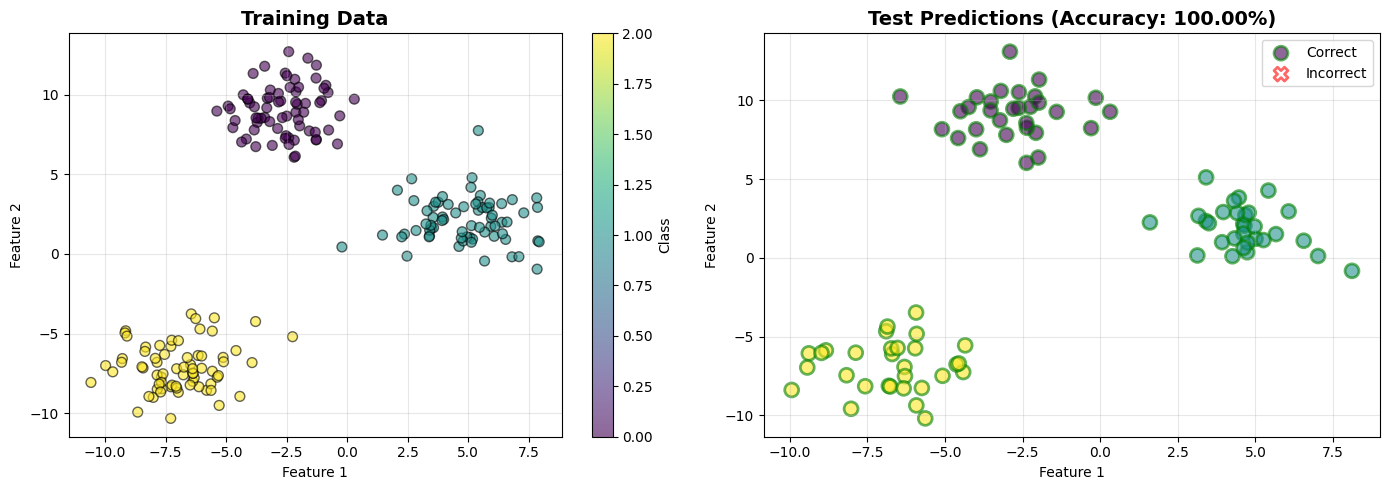

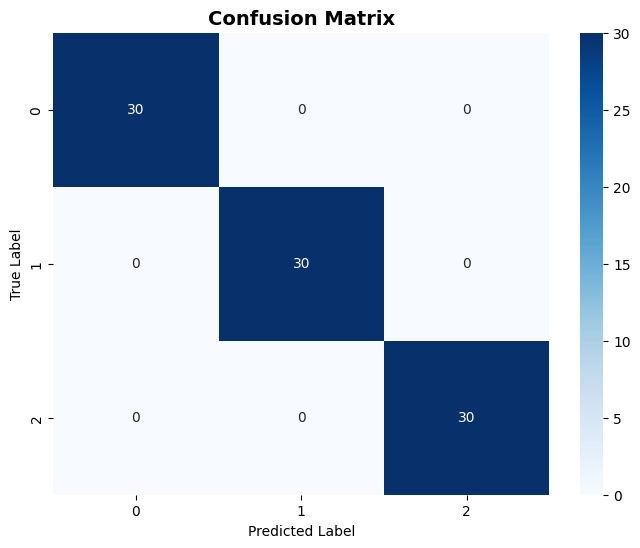

In [7]:
# Test 1: Basic KNN with 2D Classification Data
# This demonstrates the core KNN algorithm with visualization
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

print("=" * 60)
print("TEST 1: Basic KNN Classification")
print("=" * 60)

# Generate synthetic 2D classification data
X, y = make_blobs(n_samples=300, centers=3, n_features=2, 
                  random_state=42, cluster_std=1.5)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Create and train KNN classifier
knn = KNNClassifier(k=5)
knn.fit(X_train, y_train)

# Make predictions
y_pred = knn.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Training data
ax1 = axes[0]
scatter = ax1.scatter(X_train[:, 0], X_train[:, 1], c=y_train, 
                     cmap='viridis', alpha=0.6, s=50, edgecolors='black')
ax1.set_title('Training Data', fontsize=14, fontweight='bold')
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax1, label='Class')

# Plot 2: Test predictions
ax2 = axes[1]
# Plot correct predictions
correct_mask = y_test == y_pred
ax2.scatter(X_test[correct_mask, 0], X_test[correct_mask, 1], 
           c=y_pred[correct_mask], cmap='viridis', alpha=0.6, 
           s=100, marker='o', edgecolors='green', linewidths=2, label='Correct')
# Plot incorrect predictions
ax2.scatter(X_test[~correct_mask, 0], X_test[~correct_mask, 1], 
           c=y_pred[~correct_mask], cmap='viridis', alpha=0.6, 
           s=100, marker='X', edgecolors='red', linewidths=2, label='Incorrect')
ax2.set_title(f'Test Predictions (Accuracy: {accuracy:.2%})', 
             fontsize=14, fontweight='bold')
ax2.set_xlabel('Feature 1')
ax2.set_ylabel('Feature 2')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
           xticklabels=np.unique(y_test), 
           yticklabels=np.unique(y_test))
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


## Testing Strategy (TDD Approach)

### Test-Driven Development (TDD) Process

1. **Red**: Write failing tests first
2. **Green**: Write minimal code to pass tests
3. **Refactor**: Improve code while keeping tests passing

### Test Coverage

Our comprehensive test suite covers:

1. **Initialization Tests**:
   - Valid parameters
   - Invalid k (0, negative, too large)
   - Invalid distance metric

2. **Fit Method Tests**:
   - Basic fitting
   - Empty dataset
   - Mismatched X and y lengths
   - k > number of samples

3. **Distance Metric Tests**:
   - Euclidean distance
   - Manhattan distance
   - Minkowski distance
   - Invalid metric

4. **Prediction Tests**:
   - Single sample prediction
   - Multiple samples prediction
   - k=1 (1-NN)
   - k=n (all neighbors)
   - Tie-breaking
   - Single class
   - Before fitting (should raise error)

5. **Probability Tests**:
   - Probability predictions
   - Probabilities sum to 1
   - Correct class probabilities

6. **Edge Cases**:
   - Single training sample
   - Single class
   - Binary classification
   - Multi-class classification

### Why TDD?

- **Confidence**: Tests verify correctness
- **Documentation**: Tests serve as usage examples
- **Refactoring safety**: Can refactor with confidence
- **Interview**: Shows professional development practices


## Test Suite Execution


In [ ]:
# TDD: Comprehensive Test Suite
import unittest
class TestKNNClassifier(unittest.TestCase):
    
    def setUp(self):
        """Set up test fixtures."""
        # Simple 2D dataset for testing
        self.X_train = np.array([[0, 0], [1, 0], [0, 1], [1, 1], [2, 2]])
        self.y_train = np.array([0, 0, 1, 1, 0])
        self.X_test = np.array([[0.5, 0.5], [1.5, 1.5]])
    
    # ========== Initialization Tests ==========
    
    def test_initialization_valid_params(self):
        """Test initialization with valid parameters."""
        knn = KNNClassifier(k=3, distance_metric='euclidean')
        self.assertEqual(knn.k, 3)
        self.assertEqual(knn.distance_metric, 'euclidean')
    
    def test_initialization_invalid_k_zero(self):
        """Test initialization fails with k=0."""
        with self.assertRaises(ValueError):
            KNNClassifier(k=0)
    
    def test_initialization_invalid_k_negative(self):
        """Test initialization fails with negative k."""
        with self.assertRaises(ValueError):
            KNNClassifier(k=-1)
    
    def test_initialization_invalid_distance_metric(self):
        """Test initialization fails with invalid distance metric."""
        with self.assertRaises(ValueError):
            KNNClassifier(distance_metric='invalid')
    
    # ========== Fit Method Tests ==========
    
    def test_fit_basic(self):
        """Test basic fitting."""
        knn = KNNClassifier(k=3)
        knn.fit(self.X_train, self.y_train)
        np.testing.assert_array_equal(knn.X_train, self.X_train)
        np.testing.assert_array_equal(knn.y_train, self.y_train)
    
    def test_fit_empty_dataset(self):
        """Test fit fails with empty dataset."""
        knn = KNNClassifier(k=3)
        with self.assertRaises(ValueError):
            knn.fit([], [])
    
    def test_fit_mismatched_lengths(self):
        """Test fit fails when X and y have different lengths."""
        knn = KNNClassifier(k=3)
        with self.assertRaises(ValueError):
            knn.fit([[1, 2], [3, 4]], [0])
    
    def test_fit_k_too_large(self):
        """Test fit fails when k > number of samples."""
        knn = KNNClassifier(k=10)
        with self.assertRaises(ValueError):
            knn.fit(self.X_train, self.y_train)
    
    def test_fit_returns_self(self):
        """Test fit returns self for method chaining."""
        knn = KNNClassifier(k=3)
        result = knn.fit(self.X_train, self.y_train)
        self.assertIs(result, knn)
    
    # ========== Distance Metric Tests ==========
    
    def test_euclidean_distance(self):
        """Test Euclidean distance computation."""
        knn = KNNClassifier(k=3, distance_metric='euclidean')
        knn.fit(self.X_train, self.y_train)
        dist = knn._compute_distance(np.array([0, 0]), np.array([3, 4]))
        self.assertAlmostEqual(dist, 5.0, places=5)
    
    def test_manhattan_distance(self):
        """Test Manhattan distance computation."""
        knn = KNNClassifier(k=3, distance_metric='manhattan')
        knn.fit(self.X_train, self.y_train)
        dist = knn._compute_distance(np.array([0, 0]), np.array([3, 4]))
        self.assertAlmostEqual(dist, 7.0, places=5)
    
    def test_minkowski_distance(self):
        """Test Minkowski distance computation."""
        knn = KNNClassifier(k=3, distance_metric='minkowski')
        knn.fit(self.X_train, self.y_train)
        dist = knn._compute_distance(np.array([0, 0]), np.array([1, 1]))
        # Minkowski with p=3: (|0-1|^3 + |0-1|^3)^(1/3) = (2)^(1/3)
        expected = np.power(2, 1/3)
        self.assertAlmostEqual(dist, expected, places=5)
    
    # ========== Prediction Tests ==========
    
    def test_predict_before_fit(self):
        """Test predict fails before fitting."""
        knn = KNNClassifier(k=3)
        with self.assertRaises(ValueError):
            knn.predict([[0, 0]])
    
    def test_predict_single_sample(self):
        """Test prediction for single sample."""
        knn = KNNClassifier(k=3)
        knn.fit(self.X_train, self.y_train)
        pred = knn.predict([[0.5, 0.5]])
        self.assertEqual(len(pred), 1)
        self.assertIn(pred[0], [0, 1])
    
    def test_predict_multiple_samples(self):
        """Test prediction for multiple samples."""
        knn = KNNClassifier(k=3)
        knn.fit(self.X_train, self.y_train)
        pred = knn.predict(self.X_test)
        self.assertEqual(len(pred), len(self.X_test))
        self.assertTrue(all(p in [0, 1] for p in pred))
    
    def test_predict_k1(self):
        """Test prediction with k=1 (1-NN)."""
        knn = KNNClassifier(k=1)
        knn.fit(self.X_train, self.y_train)
        # Point at [0, 0] should predict class 0 (closest point)
        pred = knn.predict([[0, 0]])
        self.assertEqual(pred[0], 0)
    
    def test_predict_k_all(self):
        """Test prediction with k = number of samples."""
        knn = KNNClassifier(k=len(self.X_train))
        knn.fit(self.X_train, self.y_train)
        # Should predict majority class (0 appears 3 times, 1 appears 2 times)
        pred = knn.predict([[10, 10]])  # Far point
        self.assertEqual(pred[0], 0)  # Majority class
    
    def test_predict_tie_breaking(self):
        """Test tie-breaking in majority vote."""
        # Create scenario with tie: k=4, 2 class 0, 2 class 1
        X_tie = np.array([[0, 0], [1, 0], [0, 1], [1, 1]])
        y_tie = np.array([0, 0, 1, 1])
        knn = KNNClassifier(k=4)
        knn.fit(X_tie, y_tie)
        # Point at center should use closest neighbor for tie-breaking
        pred = knn.predict([[0.5, 0.5]])
        self.assertIn(pred[0], [0, 1])
    
    def test_predict_single_class(self):
        """Test prediction with single class in training."""
        X_single = np.array([[0, 0], [1, 1], [2, 2]])
        y_single = np.array([0, 0, 0])
        knn = KNNClassifier(k=3)
        knn.fit(X_single, y_single)
        pred = knn.predict([[1.5, 1.5]])
        self.assertEqual(pred[0], 0)
    
    # ========== Probability Tests ==========
    
    def test_predict_proba_before_fit(self):
        """Test predict_proba fails before fitting."""
        knn = KNNClassifier(k=3)
        with self.assertRaises(ValueError):
            knn.predict_proba([[0, 0]])
    
    def test_predict_proba_shape(self):
        """Test predict_proba returns correct shape."""
        knn = KNNClassifier(k=3)
        knn.fit(self.X_train, self.y_train)
        proba = knn.predict_proba(self.X_test)
        self.assertEqual(proba.shape, (len(self.X_test), len(np.unique(self.y_train))))
    
    def test_predict_proba_sums_to_one(self):
        """Test probabilities sum to 1 for each sample."""
        knn = KNNClassifier(k=3)
        knn.fit(self.X_train, self.y_train)
        proba = knn.predict_proba(self.X_test)
        for p in proba:
            self.assertAlmostEqual(np.sum(p), 1.0, places=5)
    
    def test_predict_proba_values(self):
        """Test probability values are in [0, 1]."""
        knn = KNNClassifier(k=3)
        knn.fit(self.X_train, self.y_train)
        proba = knn.predict_proba(self.X_test)
        self.assertTrue(np.all(proba >= 0))
        self.assertTrue(np.all(proba <= 1))
    
    def test_predict_proba_k1(self):
        """Test predict_proba with k=1."""
        knn = KNNClassifier(k=1)
        knn.fit(self.X_train, self.y_train)
        proba = knn.predict_proba([[0, 0]])
        # With k=1, probability should be 1.0 for the class of nearest neighbor
        self.assertTrue(np.any(proba[0] == 1.0))
    
    # ========== Integration Tests ==========
    
    def test_binary_classification(self):
        """Test binary classification scenario."""
        X = np.array([[0, 0], [1, 0], [0, 1], [1, 1]])
        y = np.array([0, 0, 1, 1])
        knn = KNNClassifier(k=3)
        knn.fit(X, y)
        pred = knn.predict([[0.2, 0.2]])
        self.assertIn(pred[0], [0, 1])
    
    def test_multi_class_classification(self):
        """Test multi-class classification."""
        X = np.array([[0, 0], [1, 0], [0, 1], [1, 1], [2, 2], [3, 3]])
        y = np.array([0, 0, 1, 1, 2, 2])
        knn = KNNClassifier(k=3)
        knn.fit(X, y)
        pred = knn.predict([[1.5, 1.5]])
        self.assertIn(pred[0], [0, 1, 2])
    
    def test_different_distance_metrics_same_result(self):
        """Test that different metrics can give different results."""
        X = np.array([[0, 0], [1, 1], [2, 2]])
        y = np.array([0, 1, 0])
        test_point = np.array([[0.5, 0.5]])
        
        knn_euclidean = KNNClassifier(k=2, distance_metric='euclidean')
        knn_euclidean.fit(X, y)
        pred_euclidean = knn_euclidean.predict(test_point)
        
        knn_manhattan = KNNClassifier(k=2, distance_metric='manhattan')
        knn_manhattan.fit(X, y)
        pred_manhattan = knn_manhattan.predict(test_point)
        
        # Results might differ, but both should be valid
        self.assertIn(pred_euclidean[0], [0, 1])
        self.assertIn(pred_manhattan[0], [0, 1])


# Run tests
if __name__ == '__main__':
    unittest.main(argv=[''], exit=False, verbosity=2)


test_binary_classification (__main__.TestKNNClassifier)
Test binary classification scenario. ... ok
test_different_distance_metrics_same_result (__main__.TestKNNClassifier)
Test that different metrics can give different results. ... ok
test_euclidean_distance (__main__.TestKNNClassifier)
Test Euclidean distance computation. ... ok
test_fit_basic (__main__.TestKNNClassifier)
Test basic fitting. ... ok
test_fit_empty_dataset (__main__.TestKNNClassifier)
Test fit fails with empty dataset. ... ok
test_fit_k_too_large (__main__.TestKNNClassifier)
Test fit fails when k > number of samples. ... ok
test_fit_mismatched_lengths (__main__.TestKNNClassifier)
Test fit fails when X and y have different lengths. ... ok
test_fit_returns_self (__main__.TestKNNClassifier)
Test fit returns self for method chaining. ... ok
test_initialization_invalid_distance_metric (__main__.TestKNNClassifier)
Test initialization fails with invalid distance metric. ... ok
test_initialization_invalid_k_negative (__main__.

## Frequently Asked Questions (FAQ)

### Q1: How does the value of k affect bias and variance?

**Answer:**
- **k=1**: 
  - High variance (overfitting) - model is very sensitive to noise
  - Low bias - can capture complex patterns
  - Decision boundary is very irregular
  - Sensitive to outliers
  
- **k=√n** (where n = number of training samples):
  - Good balance between bias and variance
  - Common heuristic for choosing k
  - Often works well in practice
  
- **k=n** (all neighbors):
  - High bias (underfitting) - model is too simple
  - Low variance - very stable predictions
  - Always predicts the majority class
  - Smooth decision boundary

**Trade-off**: As k increases, bias increases but variance decreases.

### Q2: Why is KNN called "lazy learning"?

**Answer:**
KNN is called "lazy learning" (or "instance-based learning") because:
- **No training phase**: The algorithm doesn't build a model during training
- **Just stores data**: The `fit()` method only stores the training data
- **Computation at prediction**: All computation happens during `predict()`
- **Opposite of eager learning**: Unlike algorithms like neural networks that learn parameters during training

**Implication**: Training is O(1) but prediction is O(n×d) per sample.

### Q3: What is the curse of dimensionality and how does it affect KNN?

**Answer:**
The **curse of dimensionality** refers to the phenomenon where:
- In high-dimensional spaces, all points become approximately equidistant
- Distance metrics lose their meaning
- KNN performance degrades significantly
- Nearest neighbors are no longer "near" in a meaningful way

**Example**: In 1000 dimensions, the distance between any two random points is roughly the same.

**Solutions**:
- Feature selection to reduce dimensionality
- Dimensionality reduction (PCA, t-SNE)
- Use different algorithms for high-dimensional data
- Consider using Ball Trees or LSH for high-dimensional spaces

### Q4: How would you optimize KNN for large datasets?

**Answer:**
Several optimization techniques:

1. **KD-Trees**:
   - Reduces search time from O(n) to O(log n) for low-dimensional data (d < 20)
   - Partitions space into regions
   - Not effective for high-dimensional data

2. **Ball Trees**:
   - Better than KD-trees for high-dimensional data
   - Uses hyperspheres instead of hyperplanes
   - Still degrades with very high dimensions

3. **Locality Sensitive Hashing (LSH)**:
   - Approximate nearest neighbors
   - Trade some accuracy for significant speedup
   - Good for very large datasets (millions+ samples)

4. **Feature Selection**:
   - Reduce dimensionality to improve both speed and accuracy
   - Remove irrelevant or redundant features

5. **Sampling**:
   - Use a subset of training data
   - Trade accuracy for speed

### Q5: Why is feature scaling important for KNN?

**Answer:**
KNN is **distance-based**, so feature scales matter:

- **Problem**: Features with larger scales dominate distance calculations
- **Example**: If one feature is age (0-100) and another is salary (0-200000), salary will dominate
- **Solution**: Always normalize/standardize features before using KNN
  - StandardScaler: (x - mean) / std
  - MinMaxScaler: (x - min) / (max - min)

**Without scaling**: Distance metric is biased toward features with larger ranges.

### Q6: How do you handle categorical features in KNN?

**Answer:**
Several approaches:

1. **One-Hot Encoding**:
   - Convert categorical to binary features
   - Works with standard distance metrics
   - Can increase dimensionality significantly

2. **Label Encoding + Custom Distance**:
   - Use Hamming distance for categorical features
   - Combine with Euclidean for numerical features
   - More complex implementation

3. **Mixed Distance Metrics**:
   - Use appropriate distance for each feature type
   - Weighted combination of distances

**Best Practice**: One-hot encoding is simplest and often works well.

### Q7: What about weighted KNN?

**Answer:**
**Weighted KNN** gives more weight to closer neighbors:

- **Inverse Distance Weighting**: `weight = 1 / (distance + ε)`
- Closer neighbors have more influence on prediction
- Can improve performance, especially with larger k values
- More robust to choice of k

**Implementation**: Instead of simple majority vote, use weighted voting:
```python
weights = 1 / (distances + 1e-10)  # Add small epsilon to avoid division by zero
weighted_votes = sum(weights[i] for i where label[i] == class)
```

### Q8: When should you use KNN vs other algorithms?

**Answer:**

**Use KNN when:**
- ✓ Small to medium datasets (< 10K samples)
- ✓ Non-linear decision boundaries needed
- ✓ Interpretability is important (can see which neighbors influenced decision)
- ✓ Multi-class classification
- ✓ Need probability estimates
- ✓ Data has local structure (similar instances are close)

**Don't use KNN when:**
- ✗ Large datasets (slow prediction: O(n×d) per sample)
- ✗ High-dimensional data (curse of dimensionality)
- ✗ Noisy data (sensitive to outliers)
- ✗ Real-time applications with strict latency requirements
- ✗ Need fast training (though KNN training is O(1), prediction is slow)

**Alternatives**:
- **Large datasets**: Random Forest, Gradient Boosting
- **High dimensions**: SVM with RBF kernel, Neural Networks
- **Real-time**: Pre-trained models, approximate methods

### Q9: How do you choose the optimal k value?

**Answer:**
Common strategies:

1. **Cross-Validation**:
   - Try different k values (1, 3, 5, 7, ..., √n)
   - Use k-fold cross-validation
   - Choose k with best validation accuracy

2. **Heuristics**:
   - k = √n (square root of number of samples)
   - Odd k for binary classification (avoids ties)
   - Start with k=5 or k=7

3. **Grid Search**:
   - Systematically try range of k values
   - Evaluate on validation set
   - Consider both accuracy and computational cost

**Rule of thumb**: k should be large enough to reduce noise but small enough to capture local patterns.

### Q10: What are the time and space complexities?

**Answer:**

**Time Complexity:**
- **Training**: O(1) - just stores data
- **Prediction (single sample)**: O(n×d) - compute distance to all n training points
- **Prediction (m samples)**: O(m×n×d)

**Space Complexity:**
- **O(n×d)**: Store all training data (X_train and y_train)

**Where:**
- n = number of training samples
- m = number of test samples  
- d = number of features
- k = number of neighbors (k << n typically, so doesn't affect big-O)

**Optimization**: Using KD-trees reduces prediction to O(log n×d) for low-dimensional data.


## Example Usage

### Basic Usage Example


## Interview Tips & Common Pitfalls

### What Interviewers Look For

1. **Correctness**: Does it work for all cases?
2. **Efficiency**: Time/space complexity analysis
3. **Code Quality**: Clean, readable, well-documented
4. **Edge Cases**: Handle invalid inputs, empty datasets, etc.
5. **Testing**: Write comprehensive tests
6. **Understanding**: Can you explain trade-offs and optimizations?

### Common Mistakes to Avoid

1. ❌ **Not validating k**: Allow k=0 or k > n_samples
   - ✅ Validate k in `__init__` and `fit`

2. ❌ **Not handling ties**: Don't specify tie-breaking strategy
   - ✅ Use closest neighbor's label or document the strategy

3. ❌ **Forgetting feature scaling**: Don't mention importance
   - ✅ Always normalize/standardize features for distance-based algorithms

4. ❌ **O(n) prediction time**: Don't mention optimization techniques
   - ✅ Discuss KD-trees, Ball trees, LSH for large datasets

5. ❌ **No error handling**: Assume valid inputs
   - ✅ Check for empty datasets, mismatched lengths, etc.

6. ❌ **Wrong distance metric**: Don't understand when to use which
   - ✅ Euclidean for continuous features, Manhattan for sparse data

### Key Interview Questions & Answers

**Q: How does k affect bias and variance?**
- **k=1**: High variance (overfitting), low bias, sensitive to noise
- **k=√n**: Good balance
- **k=n**: High bias (underfitting), low variance, always predicts majority class

**Q: Why is KNN called "lazy learning"?**
- No explicit training phase - just stores data
- All computation happens at prediction time
- Opposite of "eager learning" (e.g., neural networks)

**Q: What is the curse of dimensionality?**
- In high dimensions, all points become equidistant
- Distance metrics lose meaning
- KNN performance degrades significantly
- Solution: Feature selection, dimensionality reduction (PCA)

**Q: How would you optimize KNN for large datasets?**
1. **KD-Trees**: O(log n) search for low-dimensional data
2. **Ball Trees**: Better for high-dimensional data
3. **LSH**: Approximate nearest neighbors for very large datasets
4. **Feature selection**: Reduce dimensionality
5. **Sampling**: Use subset of training data

**Q: When would you use KNN vs other algorithms?**
- **Use KNN**: Small datasets, non-linear boundaries, interpretability needed
- **Don't use KNN**: Large datasets, high-dimensional data, real-time requirements

**Q: How do you handle categorical features?**
- Convert to numerical (one-hot encoding)
- Use appropriate distance metrics (Hamming distance for categorical)
- Or use mixed distance metrics

**Q: What about weighted KNN?**
- Weight neighbors by inverse distance: `weight = 1 / distance`
- Closer neighbors have more influence
- Can improve performance, especially with k > 1

### Real-World Applications

- **Recommendation systems**: "Users who bought X also bought Y"
- **Image classification**: Similar images
- **Anomaly detection**: Points far from neighbors
- **Medical diagnosis**: Similar patient cases
- **Text classification**: Similar documents

### Production Considerations

1. **Feature Scaling**: Always normalize (StandardScaler, MinMaxScaler)
2. **Missing Values**: Handle before distance computation
3. **Memory**: Store all training data (consider for large datasets)
4. **Latency**: Prediction is O(n×d) - may be too slow for real-time
5. **Model Persistence**: Save training data for deployment


## Summary & Key Takeaways

### Algorithm Summary

**KNN** is a simple yet powerful non-parametric classification algorithm that:
- Makes predictions based on k nearest neighbors
- Uses distance metrics to find similar instances
- Performs majority voting for classification
- Requires no training phase (lazy learning)

### Complexity Recap

- **Training**: O(1) - just store data
- **Prediction**: O(n×d) per sample - compute distance to all training points
- **Space**: O(n×d) - store all training data

### Best Practices

1. ✅ **Always normalize features** before using KNN
2. ✅ **Choose odd k** for binary classification to avoid ties
3. ✅ **Use cross-validation** to select optimal k
4. ✅ **Consider k=√n** as a starting point
5. ✅ **Handle edge cases** (empty data, invalid k, etc.)
6. ✅ **Use appropriate distance metric** for your data type

### Learning Resources

- **Scikit-learn**: `sklearn.neighbors.KNeighborsClassifier` for reference implementation
- **KD-Trees**: Data structure for efficient nearest neighbor search
- **Curse of Dimensionality**: Important concept for high-dimensional data
- **Bias-Variance Tradeoff**: Understanding how k affects model complexity


## Example Usage


In [ ]:
# Simple usage example
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Generate synthetic data
X, y = make_blobs(n_samples=100, centers=2, n_features=2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Create and train KNN classifier
knn = KNNClassifier(k=5, distance_metric='euclidean')
knn.fit(X_train, y_train)

# Make predictions
y_pred = knn.predict(X_test)
y_proba = knn.predict_proba(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(f"\nFirst 5 predictions: {y_pred[:5]}")
print(f"\nFirst 5 probability distributions:")
for i in range(5):
    print(f"  Sample {i+1}: {y_proba[i]}")


Accuracy: 1.0000

First 5 predictions: [0 0 1 0 0]

First 5 probability distributions:
  Sample 1: [1. 0.]
  Sample 2: [1. 0.]
  Sample 3: [0. 1.]
  Sample 4: [1. 0.]
  Sample 5: [1. 0.]


In [ ]:
# Test 2: Effect of Different K Values
# This is a common interview question: "How does k affect the model?"

print("=" * 60)
print("TEST 2: Effect of Different K Values")
print("=" * 60)

# Generate data
X, y = make_classification(n_samples=200, n_features=2, n_redundant=0, 
                          n_informative=2, n_clusters_per_class=1, 
                          random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Test different k values
k_values = [1, 3, 5, 7, 15, 25]
accuracies = []

for k in k_values:
    knn = KNNClassifier(k=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"k={k:2d}: Accuracy = {acc:.4f}")

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, k in enumerate(k_values):
    knn = KNNClassifier(k=k)
    knn.fit(X_train, y_train)
    
    # Create a mesh to plot decision boundary
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    # Predict for each point in mesh
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot decision boundary
    axes[idx].contourf(xx, yy, Z, alpha=0.4, cmap='viridis')
    axes[idx].scatter(X_train[:, 0], X_train[:, 1], c=y_train, 
                     cmap='viridis', s=30, edgecolors='black')
    axes[idx].set_title(f'k={k} (Accuracy: {accuracies[idx]:.3f})', 
                        fontweight='bold')
    axes[idx].set_xlabel('Feature 1')
    axes[idx].set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

# Plot accuracy vs k
plt.figure(figsize=(10, 5))
plt.plot(k_values, accuracies, marker='o', linewidth=2, markersize=8)
plt.xlabel('k (Number of Neighbors)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('KNN Accuracy vs k Value', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(k_values)
for k, acc in zip(k_values, accuracies):
    plt.annotate(f'{acc:.3f}', (k, acc), textcoords="offset points", 
                xytext=(0,10), ha='center')
plt.show()

print("\nKey Observations:")
print("- k=1: Very sensitive to noise, overfitting (high variance)")
print("- k=3-7: Good balance between bias and variance")
print("- k=25+: Underfitting, smoother decision boundaries (high bias)")


TEST 2: Effect of Different K Values


NameError: name 'make_classification' is not defined

TEST 3: Decision Boundary Visualization
Accuracy: 1.0000


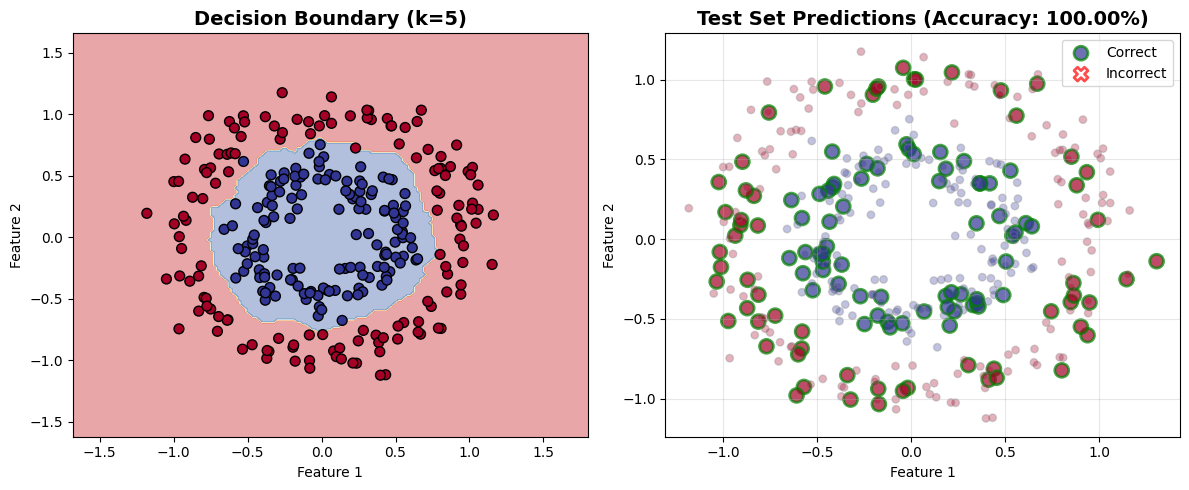

In [ ]:
# Test 3: Decision Boundary Visualization
# Shows how KNN creates non-linear decision boundaries

print("=" * 60)
print("TEST 3: Decision Boundary Visualization")
print("=" * 60)

# Generate non-linearly separable data (circles)
X, y = make_circles(n_samples=400, factor=0.5, noise=0.1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Train KNN
knn = KNNClassifier(k=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

# Create mesh for decision boundary
h = 0.02
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Predict for mesh points
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(12, 5))

# Plot 1: Decision boundary
plt.subplot(1, 2, 1)
plt.contourf(xx, yy, Z, alpha=0.4, cmap='RdYlBu')
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, 
           cmap='RdYlBu', s=50, edgecolors='black', linewidths=1)
plt.title('Decision Boundary (k=5)', fontsize=14, fontweight='bold')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

# Plot 2: Test predictions
plt.subplot(1, 2, 2)
correct_mask = y_test == y_pred
plt.scatter(X_test[correct_mask, 0], X_test[correct_mask, 1], 
           c=y_pred[correct_mask], cmap='RdYlBu', alpha=0.7, 
           s=100, marker='o', edgecolors='green', linewidths=2, label='Correct')
plt.scatter(X_test[~correct_mask, 0], X_test[~correct_mask, 1], 
           c=y_pred[~correct_mask], cmap='RdYlBu', alpha=0.7, 
           s=100, marker='X', edgecolors='red', linewidths=2, label='Incorrect')
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, 
           cmap='RdYlBu', s=30, alpha=0.3, edgecolors='gray')
plt.title(f'Test Set Predictions (Accuracy: {accuracy:.2%})', 
         fontsize=14, fontweight='bold')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


TEST 4: Distance Metrics Comparison
Euclidean   : Accuracy = 1.0000
Manhattan   : Accuracy = 1.0000
Minkowski   : Accuracy = 1.0000


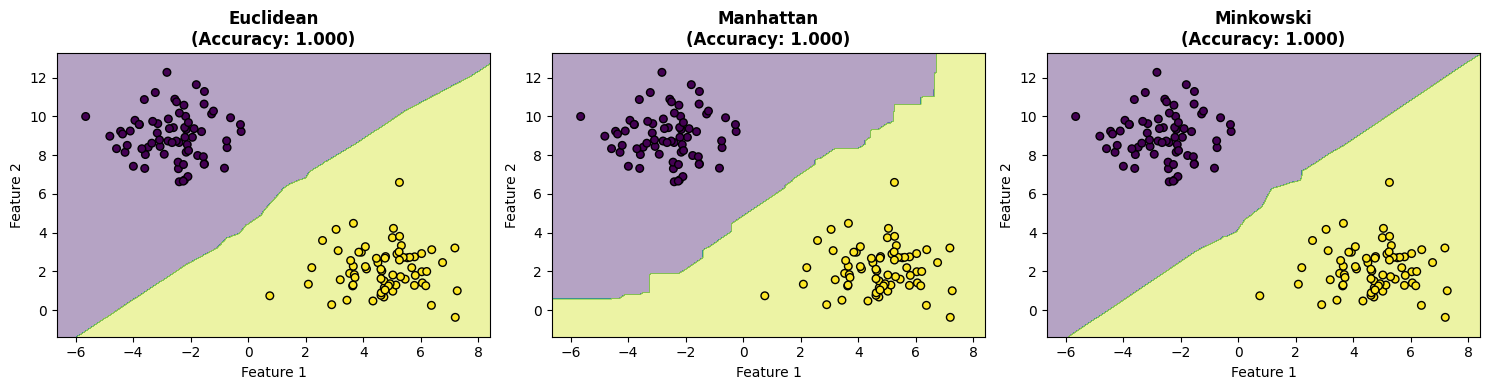


Distance Metrics Explained:
1. Euclidean: Standard straight-line distance. Good for continuous features.
2. Manhattan: Sum of absolute differences. Less sensitive to outliers.
3. Minkowski: Generalized distance (p=3 shown). More weight on larger differences.


In [ ]:
# Test 4: Distance Metrics Comparison
# Interview question: "What are different distance metrics and when to use them?"

print("=" * 60)
print("TEST 4: Distance Metrics Comparison")
print("=" * 60)

# Generate data
X, y = make_blobs(n_samples=200, centers=2, n_features=2, 
                  random_state=42, cluster_std=1.2)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

metrics = ['euclidean', 'manhattan', 'minkowski']
results = {}

for metric in metrics:
    knn = KNNClassifier(k=5, distance_metric=metric)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[metric] = acc
    print(f"{metric.capitalize():12s}: Accuracy = {acc:.4f}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, metric in enumerate(metrics):
    knn = KNNClassifier(k=5, distance_metric=metric)
    knn.fit(X_train, y_train)
    
    # Create mesh
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    axes[idx].contourf(xx, yy, Z, alpha=0.4, cmap='viridis')
    axes[idx].scatter(X_train[:, 0], X_train[:, 1], c=y_train, 
                     cmap='viridis', s=30, edgecolors='black')
    axes[idx].set_title(f'{metric.capitalize()}\n(Accuracy: {results[metric]:.3f})', 
                        fontweight='bold')
    axes[idx].set_xlabel('Feature 1')
    axes[idx].set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

print("\nDistance Metrics Explained:")
print("1. Euclidean: Standard straight-line distance. Good for continuous features.")
print("2. Manhattan: Sum of absolute differences. Less sensitive to outliers.")
print("3. Minkowski: Generalized distance (p=3 shown). More weight on larger differences.")


In [ ]:
# Test 5: Edge Cases and Interview Questions
# Common edge cases asked in interviews

print("=" * 60)
print("TEST 5: Edge Cases and Interview Scenarios")
print("=" * 60)

# Edge Case 1: k = 1 (1-NN)
print("\n1. k=1 (1-Nearest Neighbor):")
X_small, y_small = make_blobs(n_samples=50, centers=2, n_features=2, random_state=42)
X_train_small, X_test_small, y_train_small, y_test_small = train_test_split(
    X_small, y_small, test_size=0.2, random_state=42, stratify=y_small
)

knn_k1 = KNNClassifier(k=1)
knn_k1.fit(X_train_small, y_train_small)
y_pred_k1 = knn_k1.predict(X_test_small)
acc_k1 = accuracy_score(y_test_small, y_pred_k1)
print(f"   Accuracy with k=1: {acc_k1:.4f}")
print("   Note: k=1 is very sensitive to noise and outliers")

# Edge Case 2: k = n (all neighbors)
print("\n2. k = number of training samples:")
knn_kn = KNNClassifier(k=len(X_train_small))
knn_kn.fit(X_train_small, y_train_small)
y_pred_kn = knn_kn.predict(X_test_small)
acc_kn = accuracy_score(y_test_small, y_pred_kn)
print(f"   Accuracy with k={len(X_train_small)}: {acc_kn:.4f}")
print("   Note: All predictions will be the same (majority class)")

# Edge Case 3: Tie-breaking demonstration
print("\n3. Tie-breaking in majority vote:")
# Create a scenario where k=4 and we have 2 classes with 2 votes each
X_tie = np.array([[0, 0], [1, 0], [0, 1], [1, 1], [2, 2]])
y_tie = np.array([0, 0, 1, 1, 0])  # 3 class 0, 2 class 1

knn_tie = KNNClassifier(k=4)
knn_tie.fit(X_tie, y_tie)
# Predict point that's equidistant to create tie
test_point = np.array([[0.5, 0.5]])
pred = knn_tie.predict(test_point)
print(f"   Test point: {test_point[0]}")
print(f"   Prediction: {pred[0]} (uses closest neighbor in case of tie)")

# Edge Case 4: Single class
print("\n4. Single class in training data:")
X_single = np.array([[0, 0], [1, 1], [2, 2]])
y_single = np.array([0, 0, 0])
knn_single = KNNClassifier(k=3)
knn_single.fit(X_single, y_single)
pred_single = knn_single.predict(np.array([[1.5, 1.5]]))
print(f"   Prediction with single class: {pred_single[0]}")

# Edge Case 5: Invalid k
print("\n5. Error handling for invalid k:")
try:
    knn_invalid = KNNClassifier(k=100)
    knn_invalid.fit(X_train_small, y_train_small)
except ValueError as e:
    print(f"   Caught expected error: {e}")

print("\n" + "=" * 60)
print("Key Interview Points:")
print("=" * 60)
print("1. k=1: High variance, overfitting, sensitive to noise")
print("2. k=n: High bias, underfitting, always predicts majority class")
print("3. Optimal k: Usually odd number, sqrt(n) is a common starting point")
print("4. Tie-breaking: Use closest neighbor or random selection")
print("5. Lazy learning: No training phase, all computation at prediction time")
print("6. Time complexity: O(n) for each prediction (can be optimized with KD-trees)")
print("7. Space complexity: O(n) to store all training data")


TEST 5: Edge Cases and Interview Scenarios

1. k=1 (1-Nearest Neighbor):
   Accuracy with k=1: 1.0000
   Note: k=1 is very sensitive to noise and outliers

2. k = number of training samples:
   Accuracy with k=40: 1.0000
   Note: All predictions will be the same (majority class)

3. Tie-breaking in majority vote:
   Test point: [0.5 0.5]
   Prediction: 0 (uses closest neighbor in case of tie)

4. Single class in training data:
   Prediction with single class: 0

5. Error handling for invalid k:
   Caught expected error: k (100) cannot be larger than number of training samples (40)

Key Interview Points:
1. k=1: High variance, overfitting, sensitive to noise
2. k=n: High bias, underfitting, always predicts majority class
3. Optimal k: Usually odd number, sqrt(n) is a common starting point
4. Tie-breaking: Use closest neighbor or random selection
5. Lazy learning: No training phase, all computation at prediction time
6. Time complexity: O(n) for each prediction (can be optimized with KD-

TEST 6: Probability Predictions

Probability predictions for first 5 test samples:
Sample | Class 0 | Class 1 | Class 2 | Predicted
-------------------------------------------------------
  1    | 0.000  | 0.000  | 1.000  |    2
  2    | 0.000  | 0.000  | 1.000  |    2
  3    | 1.000  | 0.000  | 0.000  |    0
  4    | 0.000  | 0.000  | 1.000  |    2
  5    | 1.000  | 0.000  | 0.000  |    0


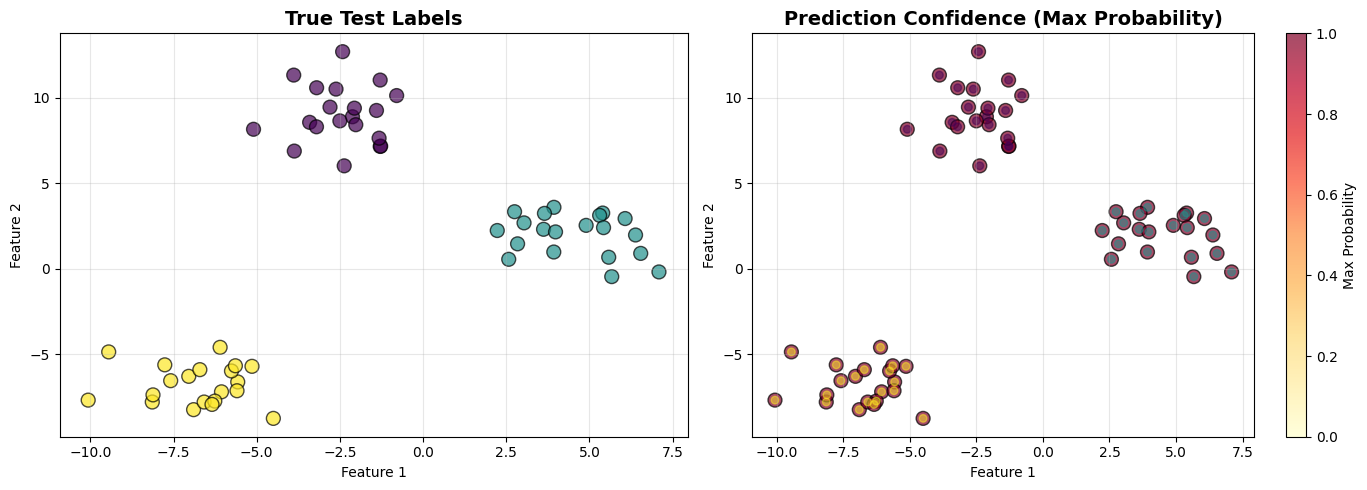


Note: Probabilities are based on the proportion of k neighbors
      belonging to each class. Higher confidence = more agreement among neighbors.


In [ ]:
# Test 6: Probability Predictions
# Shows how to get probability estimates from KNN

print("=" * 60)
print("TEST 6: Probability Predictions")
print("=" * 60)

# Generate data
X, y = make_blobs(n_samples=200, centers=3, n_features=2, 
                  random_state=42, cluster_std=1.5)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

knn = KNNClassifier(k=5)
knn.fit(X_train, y_train)

# Get probability predictions
y_proba = knn.predict_proba(X_test)
y_pred = knn.predict(X_test)

# Show probabilities for first 5 test samples
print("\nProbability predictions for first 5 test samples:")
print("Sample | Class 0 | Class 1 | Class 2 | Predicted")
print("-" * 55)
for i in range(5):
    print(f"  {i+1}    | {y_proba[i][0]:.3f}  | {y_proba[i][1]:.3f}  | {y_proba[i][2]:.3f}  |    {y_pred[i]}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: True labels
axes[0].scatter(X_test[:, 0], X_test[:, 1], c=y_test, 
               cmap='viridis', s=100, alpha=0.7, edgecolors='black')
axes[0].set_title('True Test Labels', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')
axes[0].grid(True, alpha=0.3)

# Plot 2: Predicted probabilities (using max probability as color intensity)
max_proba = np.max(y_proba, axis=1)
scatter = axes[1].scatter(X_test[:, 0], X_test[:, 1], c=max_proba, 
                         cmap='YlOrRd', s=100, alpha=0.7, 
                         edgecolors='black', vmin=0, vmax=1)
axes[1].scatter(X_test[:, 0], X_test[:, 1], c=y_pred, 
               cmap='viridis', s=30, alpha=0.5)
axes[1].set_title('Prediction Confidence (Max Probability)', 
                 fontsize=14, fontweight='bold')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
axes[1].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[1], label='Max Probability')

plt.tight_layout()
plt.show()

print("\nNote: Probabilities are based on the proportion of k neighbors")
print("      belonging to each class. Higher confidence = more agreement among neighbors.")


TEST 7: Real-world Example - Feature Scaling Impact

Interview Question: 'Why is feature scaling important for KNN?'
Answer: KNN uses distance metrics. Features with larger scales
        will dominate the distance calculation.

Accuracy without scaling: 0.7167
Accuracy with scaling:    0.9333
Improvement: 0.2167


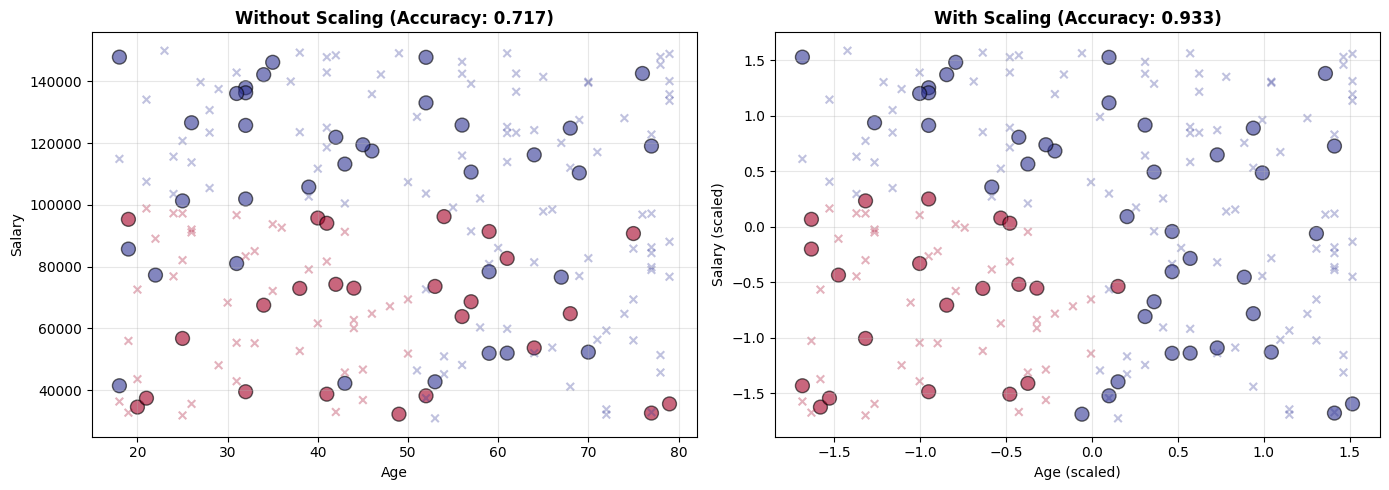


Key Takeaway:
KNN is sensitive to feature scales. Always normalize/standardize features!
Distance metrics assume all features contribute equally to distance.


In [ ]:
# Test 7: Real-world Style Example
# Simulating a classification problem with feature scaling consideration

print("=" * 60)
print("TEST 7: Real-world Example - Feature Scaling Impact")
print("=" * 60)
print("\nInterview Question: 'Why is feature scaling important for KNN?'")
print("Answer: KNN uses distance metrics. Features with larger scales")
print("        will dominate the distance calculation.\n")

# Create data with different scales
np.random.seed(42)
n_samples = 200
# Feature 1: age (0-100)
age = np.random.randint(18, 80, n_samples)
# Feature 2: salary (30000-150000)
salary = np.random.randint(30000, 150000, n_samples)
X_unscaled = np.column_stack([age, salary])

# Create labels based on age and salary
y = ((age > 50) | (salary > 100000)).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_unscaled, y, test_size=0.3, random_state=42, stratify=y
)

# Test without scaling
knn_unscaled = KNNClassifier(k=5)
knn_unscaled.fit(X_train, y_train)
y_pred_unscaled = knn_unscaled.predict(X_test)
acc_unscaled = accuracy_score(y_test, y_pred_unscaled)

# Test with scaling (normalization)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_scaled = KNNClassifier(k=5)
knn_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = knn_scaled.predict(X_test_scaled)
acc_scaled = accuracy_score(y_test, y_pred_scaled)

print(f"Accuracy without scaling: {acc_unscaled:.4f}")
print(f"Accuracy with scaling:    {acc_scaled:.4f}")
print(f"Improvement: {acc_scaled - acc_unscaled:.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Without scaling
axes[0].scatter(X_test[:, 0], X_test[:, 1], c=y_pred_unscaled, 
               cmap='RdYlBu', s=100, alpha=0.6, edgecolors='black')
axes[0].scatter(X_train[:, 0], X_train[:, 1], c=y_train, 
               cmap='RdYlBu', s=30, alpha=0.3, marker='x')
axes[0].set_title(f'Without Scaling (Accuracy: {acc_unscaled:.3f})', 
                 fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Salary')
axes[0].grid(True, alpha=0.3)

# With scaling
axes[1].scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], c=y_pred_scaled, 
               cmap='RdYlBu', s=100, alpha=0.6, edgecolors='black')
axes[1].scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, 
               cmap='RdYlBu', s=30, alpha=0.3, marker='x')
axes[1].set_title(f'With Scaling (Accuracy: {acc_scaled:.3f})', 
                 fontweight='bold')
axes[1].set_xlabel('Age (scaled)')
axes[1].set_ylabel('Salary (scaled)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey Takeaway:")
print("KNN is sensitive to feature scales. Always normalize/standardize features!")
print("Distance metrics assume all features contribute equally to distance.")


TEST 8: Complexity Analysis & Optimization
Size:  100 | Train: 0.000003s | Predict: 0.004286s
Size:  500 | Train: 0.000002s | Predict: 0.075718s
Size: 1000 | Train: 0.000002s | Predict: 0.297794s
Size: 2000 | Train: 0.000002s | Predict: 1.196649s


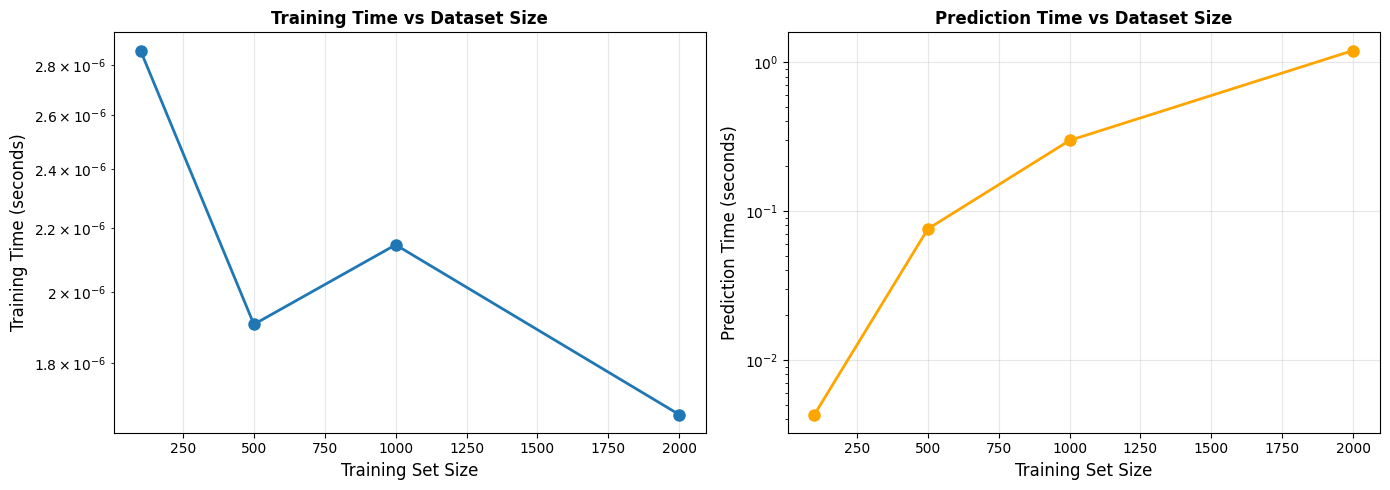


Complexity Analysis:
Training Time:  O(1) - Just stores data (lazy learning)
Prediction Time: O(n*d) where n=samples, d=features
                 - For each prediction, computes distance to all training points

Optimization Techniques:
1. KD-Trees: Reduces O(n) to O(log n) for low-dimensional data
2. Ball Trees: Better for high-dimensional data
3. Locality Sensitive Hashing (LSH): For very large datasets
4. Approximate Nearest Neighbors: Trade accuracy for speed

When to use KNN:
✓ Small to medium datasets
✓ Non-linear decision boundaries needed
✓ Interpretable predictions (can see which neighbors influenced decision)
✗ Large datasets (slow prediction)
✗ High-dimensional data (curse of dimensionality)
✗ Noisy data (sensitive to outliers)


In [ ]:
# Test 8: KNN Algorithm Complexity Analysis
# Important for interview discussions

print("=" * 60)
print("TEST 8: Complexity Analysis & Optimization")
print("=" * 60)

import time

# Test with different dataset sizes
sizes = [100, 500, 1000, 2000]
training_times = []
prediction_times = []

for size in sizes:
    X, y = make_blobs(n_samples=size, centers=3, n_features=2, random_state=42)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    knn = KNNClassifier(k=5)
    
    # Measure training time (should be ~0 for lazy learning)
    start = time.time()
    knn.fit(X_train, y_train)
    train_time = time.time() - start
    
    # Measure prediction time
    start = time.time()
    _ = knn.predict(X_test)
    pred_time = time.time() - start
    
    training_times.append(train_time)
    prediction_times.append(pred_time)
    
    print(f"Size: {size:4d} | Train: {train_time:.6f}s | Predict: {pred_time:.6f}s")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(sizes, training_times, marker='o', linewidth=2, markersize=8)
axes[0].set_xlabel('Training Set Size', fontsize=12)
axes[0].set_ylabel('Training Time (seconds)', fontsize=12)
axes[0].set_title('Training Time vs Dataset Size', fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

axes[1].plot(sizes, prediction_times, marker='o', linewidth=2, markersize=8, color='orange')
axes[1].set_xlabel('Training Set Size', fontsize=12)
axes[1].set_ylabel('Prediction Time (seconds)', fontsize=12)
axes[1].set_title('Prediction Time vs Dataset Size', fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("Complexity Analysis:")
print("=" * 60)
print("Training Time:  O(1) - Just stores data (lazy learning)")
print("Prediction Time: O(n*d) where n=samples, d=features")
print("                 - For each prediction, computes distance to all training points")
print("\nOptimization Techniques:")
print("1. KD-Trees: Reduces O(n) to O(log n) for low-dimensional data")
print("2. Ball Trees: Better for high-dimensional data")
print("3. Locality Sensitive Hashing (LSH): For very large datasets")
print("4. Approximate Nearest Neighbors: Trade accuracy for speed")
print("\nWhen to use KNN:")
print("✓ Small to medium datasets")
print("✓ Non-linear decision boundaries needed")
print("✓ Interpretable predictions (can see which neighbors influenced decision)")
print("✗ Large datasets (slow prediction)")
print("✗ High-dimensional data (curse of dimensionality)")
print("✗ Noisy data (sensitive to outliers)")
